# MSPR ObRail — Modélisation, résultats et prédictions

Ce notebook présente la comparaison de plusieurs modèles pour identifier le plus performant pour le projet ObRail.

### Modèles comparés :
1. **Régression** : Linéaire, KNN et **XGBoost** (Champion).
2. **Classification** : Logistique, KNN et **XGBoost** (Champion).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor, XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'raw' / 'eu_trips_v2.csv'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DIESEL_CO2_FACTOR = 2.68
SCENARIOS = {
    'reference': {'conso_adj': 1.0, 'dist_adj': 1.0},
    'diesel_50_electrique': {'conso_adj': 0.5, 'dist_adj': 1.0},
    'conso_moins_15': {'conso_adj': 0.85, 'dist_adj': 1.0},
    'distance_moins_10': {'conso_adj': 0.9, 'dist_adj': 0.9}
}

## 1. Préparation des données et Feature Engineering

Nous préparons les cibles de Régression (CO2 futur) et de Classification (Substitution Avion).

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

def prepare_data(df_in):
    df = df_in.copy()
    for col in ['distance_km', 'duration_minutes', 'consommation_totale', 'gco2_per_kwh']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
    
    frames = []
    for name, adj in SCENARIOS.items():
        temp = df.copy()
        temp['scenario'] = name
        temp['future_kgco2'] = (temp['consommation_totale'] * adj['conso_adj'] * temp['gco2_per_kwh']) / 1000.0
        frames.append(temp)
    
    full_df = pd.concat(frames, ignore_index=True)
    full_df['substitution_avion'] = ((full_df['distance_km'] > 300) & (full_df['duration_minutes'] < 480)).astype(int)
    return full_df

df_model = prepare_data(df_raw)
num_features = ['distance_km', 'duration_minutes', 'consommation_totale', 'gco2_per_kwh']
cat_features = ['country', 'type_train', 'scenario']
X = df_model[num_features + cat_features]
y_reg = df_model['future_kgco2']
y_clf = df_model['substitution_avion']

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

## 2. Pipeline de Prétraitement

Standardisation et encodage.

In [3]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

## 3. Entraînement et Comparaison des modèles

Nous testons plusieurs algorithmes pour sélectionner le plus performant.

In [4]:
reg_models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('algo', LinearRegression())]),
    'KNN Regressor': Pipeline([('prep', preprocessor), ('algo', KNeighborsRegressor(n_neighbors=7))]),
    'XGBoost Regressor': Pipeline([('prep', preprocessor), ('algo', XGBRegressor(n_estimators=100))])
}

clf_models = {
    'Logistic Regression': Pipeline([('prep', preprocessor), ('algo', LogisticRegression(max_iter=1000))]),
    'KNN Classifier': Pipeline([('prep', preprocessor), ('algo', KNeighborsClassifier(n_neighbors=9))]),
    'XGBoost Classifier': Pipeline([('prep', preprocessor), ('algo', XGBClassifier(n_estimators=100))])
}

X_sample = X_train.sample(20000, random_state=42)
y_reg_sample = y_train_reg.loc[X_sample.index]
y_clf_sample = y_train_clf.loc[X_sample.index]

results_reg = {}
for name, model in reg_models.items():
    model.fit(X_sample, y_reg_sample)
    y_pred = model.predict(X_test)
    results_reg[name] = {
        'MAE': mean_absolute_error(y_test_reg, y_pred),
        'RMSE': mean_squared_error(y_test_reg, y_pred)**0.5,
        'R2': r2_score(y_test_reg, y_pred)
    }

results_clf = {}
for name, model in clf_models.items():
    model.fit(X_sample, y_clf_sample)
    y_pred = model.predict(X_test)
    results_clf[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'F1-Score': f1_score(y_test_clf, y_pred)
    }

display(pd.DataFrame(results_reg).T)
display(pd.DataFrame(results_clf).T)

,MAE,RMSE,R2
Linear Regression,181.699,327.172,0.499
KNN Regressor,5.933,44.424,0.991
XGBoost Regressor,2.434,12.236,0.999


,Accuracy,F1-Score
Logistic Regression,0.987,0.919
KNN Classifier,0.996,0.978
XGBoost Classifier,0.998,0.990


## 4. Visualisation de la performance (Champion : XGBoost)

Benchmark visuel incluant les courbes ROC et l'importance des variables.

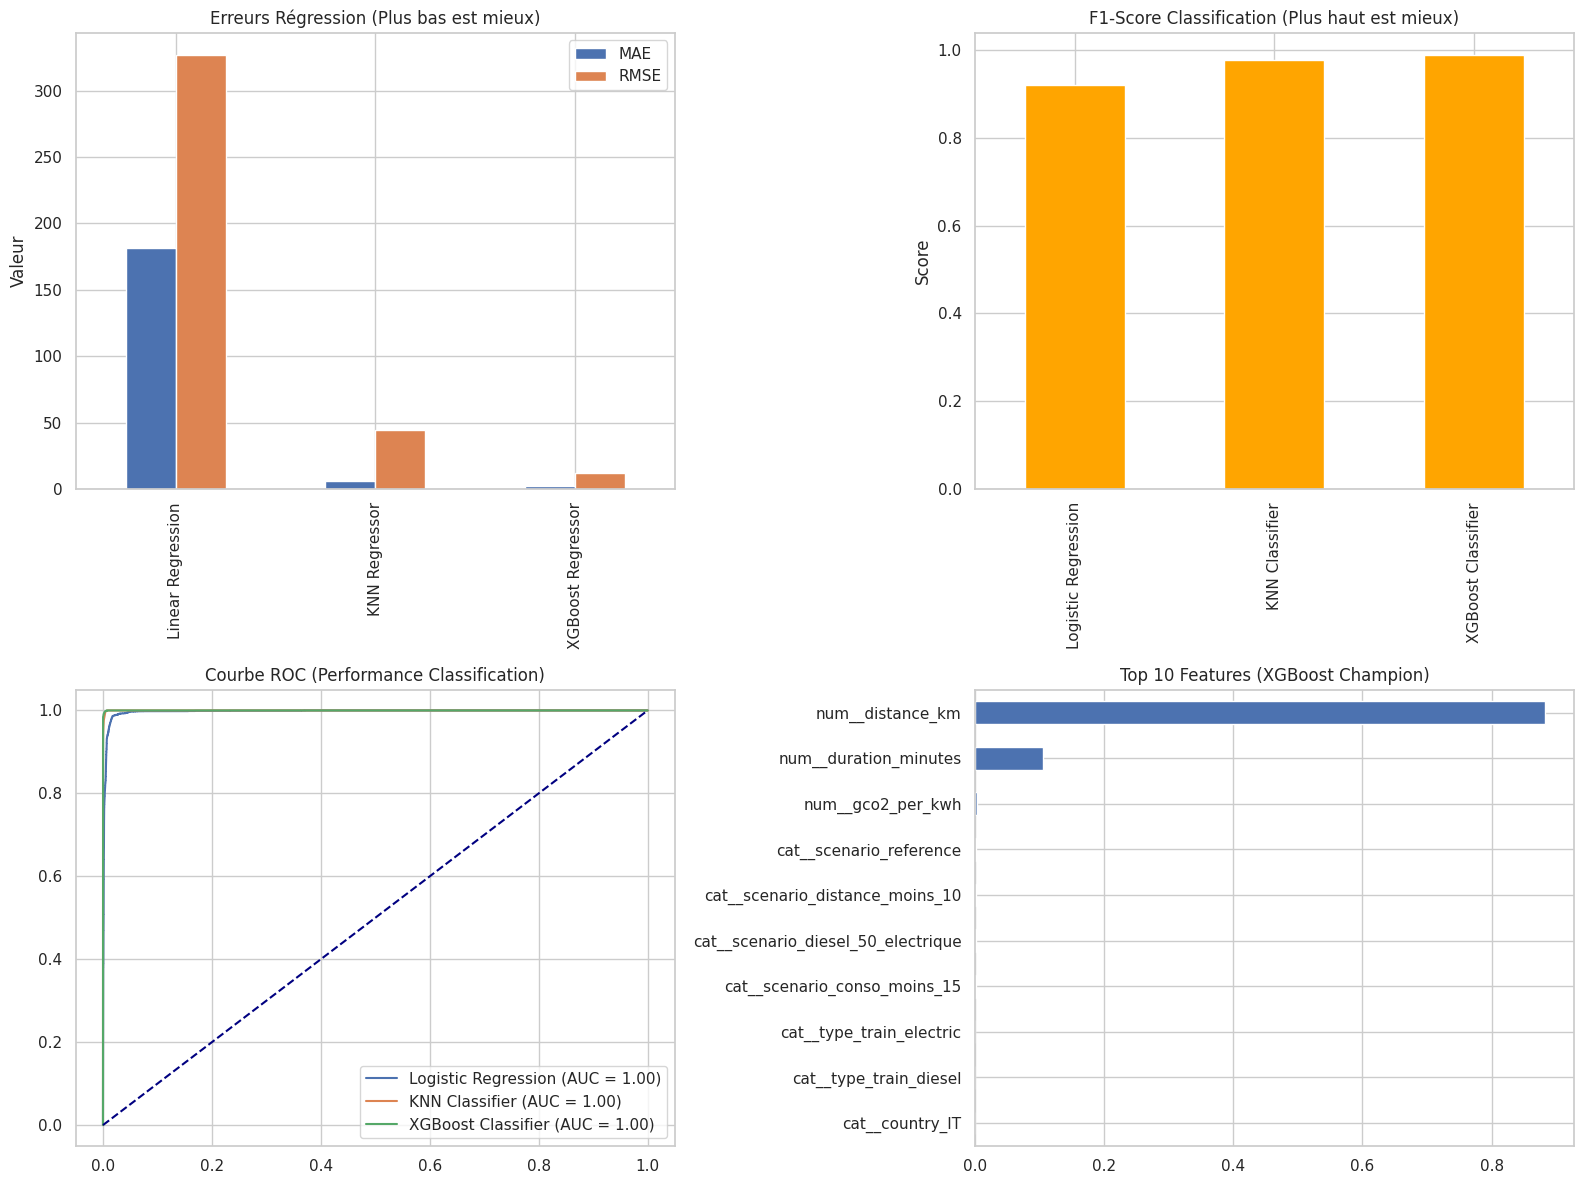

In [5]:
df_reg_metrics = pd.DataFrame(results_reg).T
df_clf_metrics = pd.DataFrame(results_clf).T

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Erreurs Régression
df_reg_metrics[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0, 0], title="Erreurs Régression (Plus bas est mieux)")
axes[0, 0].set_ylabel("Valeur")

# 2. F1-Score Classification
df_clf_metrics['F1-Score'].plot(kind='bar', ax=axes[0, 1], color='orange', title="F1-Score Classification (Plus haut est mieux)")
axes[0, 1].set_ylabel("Score")

# 3. Courbes ROC
for name, model in clf_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_clf, y_score)
        roc_auc = auc(fpr, tpr)
        axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1, 0].set_title("Courbe ROC (Performance Classification)")
axes[1, 0].legend(loc="lower right")

# 4. Feature Importance (XGBoost Champion)
champion_clf = clf_models['XGBoost Classifier'].named_steps['algo']
importance = pd.Series(champion_clf.feature_importances_, index=preprocessor.get_feature_names_out())
importance.sort_values().tail(10).plot(kind='barh', ax=axes[1, 1], title="Top 10 Features (XGBoost Champion)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_benchmark_visuals.png')
plt.show()

## 5. Export des modèles Champions pour l'API

Sauvegarde des modèles XGBoost.

In [6]:
joblib.dump(reg_models['XGBoost Regressor'], MODELS_DIR / 'regression_co2.joblib')
joblib.dump(clf_models['XGBoost Classifier'], MODELS_DIR / 'classification_substitution_avion.joblib')
print("Modèles champions exportés avec succès.")

Modèles champions exportés avec succès.
